In [7]:
import pandas as pd
import yfinance as yf

In [8]:
# Download Apple stock data
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [9]:
# Show first 5 rows
print(df.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400505  72.460769  71.156667  71.409770  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928040  72.533080  71.708680  72.277563  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200


In [10]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1258, 5)


In [13]:
from ta.trend import SMAIndicator

In [14]:
# Create 10-day Simple Moving Average
df["SMA_10"] = SMAIndicator(df["Close"], window=10).sma_indicator()

ValueError: Data must be 1-dimensional, got ndarray of shape (1258, 1) instead

In [15]:
# Create 10-day Simple Moving Average
df["SMA_10"] = SMAIndicator(close=df["Close"].squeeze(), window=10).sma_indicator()

In [16]:
df[["Close", "SMA_10"]].tail()

Price,Close,SMA_10
Ticker,AAPL,
Date,,
2024-12-24,256.797241,249.924747
2024-12-26,257.612732,251.170938
2024-12-27,254.201370,251.929790
2024-12-30,250.829788,252.334578
2024-12-31,249.059464,252.272914


In [17]:
from ta.momentum import RSIIndicator

In [18]:
df["RSI"] = RSIIndicator(close=df["Close"].squeeze(), window=14).rsi()

In [19]:
df[["Close", "SMA_10", "RSI"]].tail()

Price,Close,SMA_10,RSI
Ticker,AAPL,,
Date,,,
2024-12-24,256.797241,249.924747,75.750281
2024-12-26,257.612732,251.170938,76.452855
2024-12-27,254.201370,251.929790,67.626245
2024-12-30,250.829788,252.334578,60.225563
2024-12-31,249.059464,252.272914,56.715902


In [20]:
df["Tomorrow_Close"] = df["Close"].shift(-1)

In [21]:
# Create target variable
df["Target"] = (df["Tomorrow_Close"] > df["Close"]).astype(int)

ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1, copy=False)` before operating.

In [22]:
# Create target variable
df["Target"] = (
    df["Tomorrow_Close"].squeeze() > df["Close"].squeeze()
).astype(int)

In [23]:
df[["Close", "SMA_10", "RSI", "Tomorrow_Close", "Target"]].tail()

Price,Close,SMA_10,RSI,Tomorrow_Close,Target
Ticker,AAPL,,,,
Date,,,,,
2024-12-24,256.797241,249.924747,75.750281,257.612732,1
2024-12-26,257.612732,251.170938,76.452855,254.201370,0
2024-12-27,254.201370,251.929790,67.626245,250.829788,0
2024-12-30,250.829788,252.334578,60.225563,249.059464,0
2024-12-31,249.059464,252.272914,56.715902,NaN,0


In [24]:
# Remove missing values
df = df.dropna()

In [25]:
# Select input features
features = ["Close", "SMA_10", "RSI"]

X = df[features]
y = df["Target"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [30]:
# Train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
# Make predictions
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5261044176706827


In [34]:
# Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

print(importance)

  Feature  Importance
0   Close    0.325422
1  SMA_10    0.330003
2     RSI    0.344575


In [35]:
import matplotlib.pyplot as plt

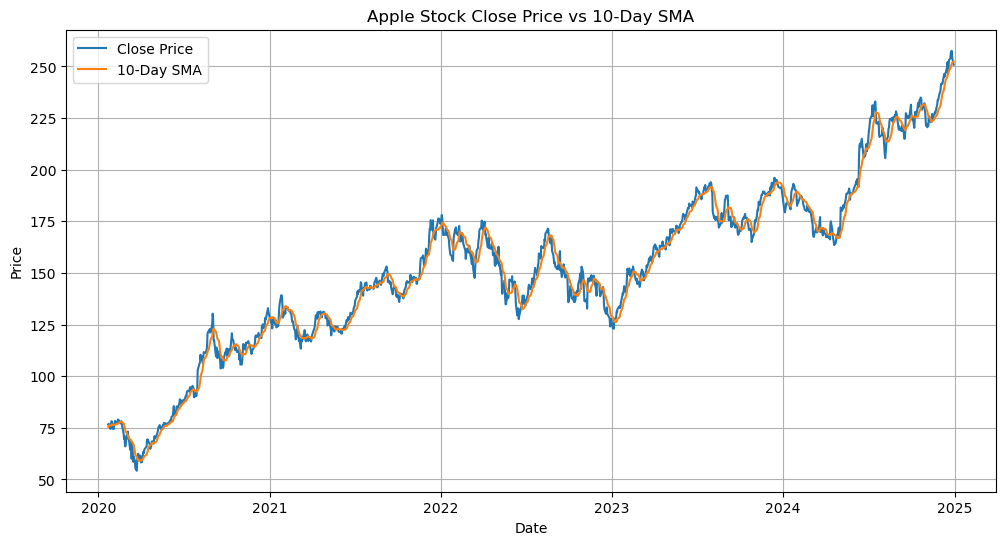

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["SMA_10"], label="10-Day SMA")

plt.title("Apple Stock Close Price vs 10-Day SMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [40]:
for name, clf in models.items():
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.5020080321285141
Decision Tree Accuracy: 0.5060240963855421
Random Forest Accuracy: 0.5261044176706827


In [41]:
results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    acc = accuracy_score(y_test, predictions)

    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.502008
1        Decision Tree  0.506024
2        Random Forest  0.526104


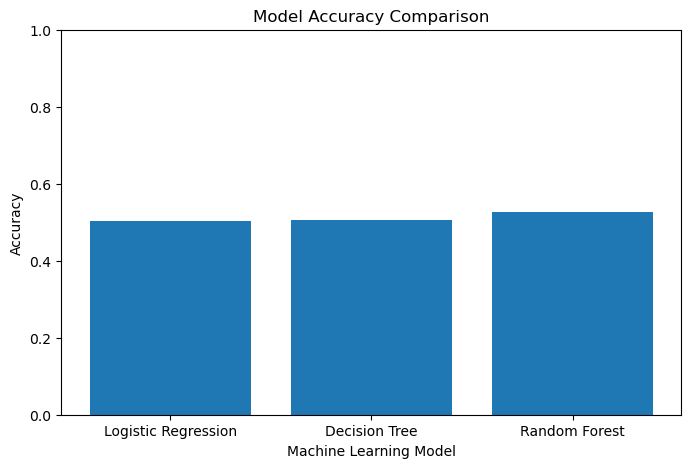

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [43]:
import joblib

In [44]:
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

joblib.dump(final_model, "stock_movement_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [45]:
joblib.dump(features, "features.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!
